# Detecção e Reconstrução de Malha Viária a partir de Imagens de Satélite

**Disciplina:** Reconhecimento de Padrões  
**Integrantes:** Beatriz Vocurca Frade, Johnatan Augusto Moreira do Carmo e Marina Alves Resende

Este notebook implementa um pipeline de visão computacional clássica para detectar vias, gerar máscaras segmentadas, sobrepor o resultado na imagem original e extrair um grafo da malha viária.

## 0. Setup

In [55]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR     = PROJECT_ROOT / "data" / "raw"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
GRAPHS_DIR  = PROJECT_ROOT / "data" / "graphs"

RAW_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raiz: {PROJECT_ROOT}")


Raiz: /content


In [56]:

# ---------------------------------------------------------------------------
# Upload de imagens para data/raw/
# Arraste ou selecione arquivos de imagem. Eles serao salvos em RAW_DIR.
# Execute esta celula e use o botao que aparece abaixo.
# ---------------------------------------------------------------------------

import ipywidgets as widgets
from IPython.display import display

uploader = widgets.FileUpload(
    accept=".png,.jpg,.jpeg,.bmp,.tif,.tiff",
    multiple=True,
    description="Enviar imagens",
    layout=widgets.Layout(width="300px"),
)

status_out = widgets.Output()

def _on_upload(change):
    with status_out:
        status_out.clear_output()
        for fname, fdata in uploader.value.items():
            dest = RAW_DIR / fname
            dest.write_bytes(fdata["content"])
            print(f"Salvo: {dest}")

uploader.observe(_on_upload, names="value")
display(widgets.VBox([uploader, status_out]))


## 1. Imports

In [64]:
import math
import warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from skimage.morphology import skeletonize

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110

print("Bibliotecas carregadas.")


Bibliotecas carregadas.


## 2. Leitura da imagem

Lista imagens em `data/raw/`. Usa imagem sintética se a pasta estiver vazia.

In [65]:
SUPPORTED_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}


def list_images(raw_dir: Path) -> list:
    raw_dir.mkdir(parents=True, exist_ok=True)
    return sorted(p for p in raw_dir.iterdir()
                  if p.is_file() and p.suffix.lower() in SUPPORTED_EXTENSIONS)


def load_rgb(path: Path) -> np.ndarray:
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError(f"Nao foi possivel carregar: {path}")
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)


def synthetic_image(size: int = 768) -> np.ndarray:
    """Imagem sintetica para teste quando nao ha imagens reais."""
    rng = np.random.default_rng(42)
    img = np.zeros((size, size, 3), dtype=np.uint8)
    # Fundo: vegetacao e solo variado
    img[..., 0] = rng.normal(75, 20, (size, size)).clip(0, 255)
    img[..., 1] = rng.normal(100, 25, (size, size)).clip(0, 255)
    img[..., 2] = rng.normal(65, 20, (size, size)).clip(0, 255)
    # Vias (asfalto e terra)
    roads = [
        ((50, 150), (720, 180), 26, (120, 118, 110)),
        ((100, 80),  (500, 700), 20, (105, 102, 95)),
        ((50, 500),  (730, 440), 22, (140, 115, 75)),
        ((430, 30),  (470, 730), 18, (125, 122, 115)),
        ((100, 650), (680, 250), 15, (110, 107, 100)),
    ]
    for p1, p2, w, color in roads:
        cv2.line(img, p1, p2, color, w, lineType=cv2.LINE_AA)
    # Edificacoes e blocos
    for _ in range(50):
        x, y = rng.integers(0, size - 80, 2)
        bw, bh = rng.integers(20, 60, 2)
        c = tuple(int(v) for v in rng.normal([130, 125, 118], 20).clip(0, 255))
        cv2.rectangle(img, (int(x), int(y)), (int(x + bw), int(y + bh)), c, -1)
    return img


# Carrega a primeira imagem disponivel, ou usa sintetica
imgs = list_images(RAW_DIR)
if imgs:
    img_rgb = load_rgb(imgs[0])
    print(f"Imagem: {imgs[0].name}  shape: {img_rgb.shape}")
else:
    img_rgb = synthetic_image()
    print(f"Nenhuma imagem encontrada. Usando sintetica.  shape: {img_rgb.shape}")


Imagem: rural.png  shape: (319, 641, 3)


## 3. Pre-processamento

Redimensiona se necessario, aplica filtro bilateral (denoising) e CLAHE no canal L para equalizar o contraste sem saturar cores.

In [66]:
def odd(v: int, mn: int = 3) -> int:
    """Retorna inteiro impar >= mn."""
    v = max(mn, int(v))
    return v if v % 2 == 1 else v + 1


def resize_max(rgb: np.ndarray, max_side: int = 1400) -> tuple:
    """Redimensiona mantendo proporcao se lado > max_side."""
    h, w = rgb.shape[:2]
    scale = min(1.0, max_side / max(h, w))
    if scale >= 1.0:
        return rgb.copy(), 1.0
    new_size = (int(w * scale), int(h * scale))
    return cv2.resize(rgb, new_size, interpolation=cv2.INTER_AREA), scale


def preprocess(rgb: np.ndarray, max_side: int = 1400) -> dict:
    """
    1. Redimensiona para max_side
    2. Bilateral filter (preserva bordas, reduz ruido)
    3. CLAHE no canal L (equaliza contraste)
    Retorna dict com: rgb, enhanced, gray, hsv, scale
    """
    img, scale = resize_max(rgb, max_side)

    # Denoising que preserva bordas (importantes para detectar vias)
    dn = cv2.bilateralFilter(img, d=7, sigmaColor=50, sigmaSpace=50)

    # CLAHE no canal L do espaco LAB
    lab = cv2.cvtColor(dn, cv2.COLOR_RGB2LAB)
    l_ch, a_ch, b_ch = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8))
    l_eq = clahe.apply(l_ch)
    enhanced = cv2.cvtColor(cv2.merge([l_eq, a_ch, b_ch]), cv2.COLOR_LAB2RGB)

    gray = cv2.cvtColor(enhanced, cv2.COLOR_RGB2GRAY)
    hsv  = cv2.cvtColor(enhanced, cv2.COLOR_RGB2HSV)

    return {"rgb": img, "enhanced": enhanced, "gray": gray, "hsv": hsv, "scale": scale}


pre = preprocess(img_rgb)
print(f"Shape apos resize: {pre['rgb'].shape}  escala: {pre['scale']:.3f}")


Shape apos resize: (319, 641, 3)  escala: 1.000


## 4. Deteccao de vias - mascara binaria

Pipeline de 3 cues independentes combinados em mapa de probabilidade:

1. **Frangi vesselness** - Hessiana multi-escala (sigma 3, 6, 11, 18) calibrada para largura real de vias
2. **Top-hat direcional** - morfologico em 6 orientacoes x 3 escalas; detecta cristas claras E escuras
3. **Score de cor** - funcao suave para asfalto, terra e concreto; penaliza vegetacao/sombra/agua

Combinacao: `prob = 0.55 * max(Frangi, TopHat) + 0.45 * Cor` com limiar adaptativo (percentil 78%).

In [67]:
# ---------------------------------------------------------------------------
# Cue 1: Filtro de Frangi (Hessiana multi-escala)
# Sigmas calibrados para LARGURA de via: sigma ~ metade da largura em px.
# Vias reais: 6-20px largura → sigmas 2.5 a 8.
# Sigmas grandes (>10) detectam bordas de campos → EXCLUIDOS.
# ---------------------------------------------------------------------------

def frangi_vesselness(
    gray: np.ndarray,
    sigmas: tuple = (2.0, 4.0, 7.0),
    beta: float = 0.5,
) -> np.ndarray:
    """
    Frangi 2D: autovalores da Hessiana em multiplas escalas.
    Sigmas (2, 4, 7) cobrem vias de ~4 a ~14px de meia-largura.
    Retorna mapa float32 [0,1].
    """
    img = gray.astype(np.float32)
    vessel = np.zeros_like(img)

    for sigma in sigmas:
        k = odd(int(sigma * 6), mn=3)
        bl = cv2.GaussianBlur(img, (k, k), sigma)

        Ixx = cv2.Sobel(bl, cv2.CV_32F, 2, 0, ksize=3) * (sigma ** 2)
        Iyy = cv2.Sobel(bl, cv2.CV_32F, 0, 2, ksize=3) * (sigma ** 2)
        Ixy = cv2.Sobel(bl, cv2.CV_32F, 1, 1, ksize=3) * (sigma ** 2)

        tr   = (Ixx + Iyy) / 2.0
        disc = np.sqrt(np.maximum(((Ixx - Iyy) / 2.0) ** 2 + Ixy ** 2, 0))
        lam1, lam2 = tr + disc, tr - disc

        lam_a = np.where(np.abs(lam1) <= np.abs(lam2), lam1, lam2)  # menor magnitude
        lam_b = np.where(np.abs(lam1) >  np.abs(lam2), lam1, lam2)  # maior magnitude

        Rb = lam_a / (lam_b + np.sign(lam_b + 1e-10) * 1e-6)
        S  = np.sqrt(lam_a ** 2 + lam_b ** 2)
        c  = max(float(np.percentile(S, 99)) * 0.25, 1e-5)

        v = np.exp(-(Rb ** 2) / (2 * beta ** 2)) * (1.0 - np.exp(-(S ** 2) / (2 * c ** 2)))
        v[np.abs(lam_b) < 1e-5] = 0.0
        vessel = np.maximum(vessel, v.astype(np.float32))

    return (vessel / (vessel.max() + 1e-9)).astype(np.float32)


# ---------------------------------------------------------------------------
# Cue 2: Top-hat direcional (morfologico)
# Linhas curtas (proporcional ao tamanho da imagem, maximo ~35px)
# para nao responder a bordas de grandes campos.
# ---------------------------------------------------------------------------

def directional_tophat(gray: np.ndarray, min_side: int) -> np.ndarray:
    """
    Top-hat em 6 orientacoes x 2 escalas.
    Linhas curtas (max ~35px) → detecta so estruturas estreitas (vias).
    """
    g = gray.astype(np.float32)
    acc = np.zeros_like(g)

    line_lengths = [
        max(12, min_side // 80),   # escala menor
        max(24, min_side // 45),   # escala maior (cap em ~35px)
    ]
    # Garante que nao detecte estruturas muito largas
    line_lengths = [min(ll, 35) for ll in line_lengths]

    for ll in line_lengths:
        for deg in range(0, 180, 30):
            ang  = np.deg2rad(deg)
            dx   = int(round(np.cos(ang) * ll / 2))
            dy   = int(round(np.sin(ang) * ll / 2))
            half = max(abs(dx), abs(dy), 1)
            ks   = half * 2 + 1
            k    = np.zeros((ks, ks), dtype=np.uint8)
            cv2.line(k, (half - dx, half - dy), (half + dx, half + dy), 1, 1)

            wth = (g - cv2.morphologyEx(gray, cv2.MORPH_OPEN,  k).astype(np.float32)).clip(0)
            bth = (cv2.morphologyEx(gray, cv2.MORPH_CLOSE, k).astype(np.float32) - g).clip(0)
            acc = np.maximum(acc, np.maximum(wth, bth))

    return (acc / (acc.max() + 1e-9)).astype(np.float32)


# ---------------------------------------------------------------------------
# Cue 3: Score de cor (funcao suave)
# IMPORTANTE: solo agricola nao e via. Penalidade elevada para grandes areas
# homogeneas de solo (campos) e para saturacao alta (terra/solo tipico).
# ---------------------------------------------------------------------------

def road_color_score(pre: dict) -> np.ndarray:
    """
    Score suave [0,1]. Cobre asfalto (cinza), terra/cascalho (quente),
    concreto (claro). Penaliza vegetacao, sombra, agua e grandes manchas de solo.
    """
    rgb = pre["enhanced"]
    hsv = pre["hsv"]
    h_ch, s_ch, v_ch = [ch.astype(np.float32) for ch in cv2.split(hsv)]

    r = rgb[..., 0].astype(np.float32)
    g = rgb[..., 1].astype(np.float32)
    b = rgb[..., 2].astype(np.float32)
    spread = np.maximum.reduce([r, g, b]) - np.minimum.reduce([r, g, b])

    # Asfalto: baixa saturacao, cinzento, brilho medio
    asp = (
        np.clip(1.0 - s_ch / 60.0, 0, 1)
        * np.clip(1.0 - spread / 40.0, 0, 1)
        * np.clip((v_ch - 35.0) / 55.0, 0, 1)
        * np.clip((230.0 - v_ch) / 80.0, 0, 1)
    )

    # Terra/cascalho: tom quente, saturacao BAIXA-a-MEDIA
    # (solo agricola tem s_ch alto → penalizado abaixo)
    warm  = np.clip((r - b - 10.0) / 40.0, 0, 1)
    s_low = np.clip((60.0 - s_ch) / 40.0, 0, 1)   # prefere saturacao baixa (pavimento)
    v_fit = np.clip((v_ch - 55.0) / 70.0, 0, 1)
    dirt  = warm * s_low * v_fit

    # Concreto claro: alto valor, baixa saturacao
    conc = np.clip((v_ch - 160.0) / 60.0, 0, 1) * np.clip(1.0 - s_ch / 50.0, 0, 1)

    score = np.maximum.reduce([asp, dirt, conc])

    # Penalidades
    excess_g  = (2.0 * g - r - b)
    veg_pen   = np.clip(excess_g / 35.0, 0, 1) * (g > r + 4).astype(np.float32)
    dark_pen  = np.clip((30.0 - v_ch) / 22.0, 0, 1)
    water_pen = np.clip((b - r - 18.0) / 28.0, 0, 1) * np.clip((75.0 - v_ch) / 40.0, 0, 1)
    # Penalidade extra para solo muito saturado (campos agricolas)
    soil_pen  = np.clip((s_ch - 55.0) / 45.0, 0, 1) * np.clip((r - b - 5.0) / 30.0, 0, 1)

    penalty = np.clip(veg_pen * 1.5 + dark_pen + water_pen + soil_pen * 1.2, 0, 1)
    return np.clip(score * (1.0 - penalty), 0, 1).astype(np.float32)


# ---------------------------------------------------------------------------
# Limpeza morfologica e filtragem de componentes
# Usa transformada de distancia para medir a largura MAXIMA de cada componente.
# Campos agricolas tem ponto mais largo >> largura maxima de via.
# Este teste e muito mais discriminativo que area/esqueleto (media).
# ---------------------------------------------------------------------------

def postprocess_mask(
    mask: np.ndarray,
    min_area_ratio: float = 1.5e-4,
    max_area_ratio: float = 0.05,
    min_elongation: float = 2.5,
) -> np.ndarray:
    """
    1. Fechamento + abertura morfologicos
    2. Transformada de distancia: max_half_width por componente
       - Via: max_half_width em [min_half_w, max_half_w]
       - Campo/blob: max_half_width >> max_half_w  → descartado
    3. Filtra por area e elongacao (filtro secundario)
    """
    H, W = mask.shape
    total = H * W
    min_side = min(H, W)

    # Faixa de meia-largura valida para uma via (em pixels)
    min_half_w = 2.0                          # trilha muito fina: ~4px total
    max_half_w = float(max(14, min_side // 48))  # ~14-18px para imagem tipica = ~36px total

    m = mask.astype(np.uint8) * 255

    ck = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (odd(min_side // 100, 5),) * 2)
    ok = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (odd(min_side // 280, 3),) * 2)
    m = cv2.morphologyEx(m, cv2.MORPH_CLOSE, ck, iterations=2)
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN,  ok, iterations=1)

    # Transformada de distancia Euclidiana: valor em cada pixel = distancia ate borda
    # Em um componente, o maximo = meia-largura do ponto mais largo
    dist = cv2.distanceTransform(m, cv2.DIST_L2, 5)

    min_area = max(50, int(total * min_area_ratio))
    max_area = int(total * max_area_ratio)

    n, labels, stats, _ = cv2.connectedComponentsWithStats(m, connectivity=8)
    keep = np.zeros((H, W), dtype=np.uint8)

    for lbl in range(1, n):
        area  = int(stats[lbl, cv2.CC_STAT_AREA])
        bw    = int(stats[lbl, cv2.CC_STAT_WIDTH])
        bh    = int(stats[lbl, cv2.CC_STAT_HEIGHT])
        elong = max(bw, bh) / max(1, min(bw, bh))
        fill  = area / max(1, bw * bh)

        if area < min_area:
            continue

        # Filtro de largura (mais importante): usa max da transformada de distancia
        comp_mask = labels == lbl
        max_local_hw = float(dist[comp_mask].max())  # meia-largura maxima
        if max_local_hw < min_half_w:
            continue  # muito fino: ruido de 1-2px
        if max_local_hw > max_half_w:
            continue  # muito largo: campo, lago, telhado grande

        # Filtros secundarios por area e forma
        if area > max_area and elong < min_elongation:
            continue
        if area > max_area * 0.2 and fill > 0.65 and elong < min_elongation:
            continue

        keep[labels == lbl] = 255

    lk = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (odd(min_side // 160, 3),) * 2)
    keep = cv2.morphologyEx(keep, cv2.MORPH_CLOSE, lk, iterations=1)
    return keep > 0


# ---------------------------------------------------------------------------
# Pipeline principal de deteccao
# ---------------------------------------------------------------------------

def detect_roads(pre: dict) -> np.ndarray:
    """
    Combina 3 cues em mapa de probabilidade:
      - Frangi (sigmas 2, 4, 7): estruturas estreitas
      - Top-hat direcional (linhas curtas): cristas claras/escuras
      - Score de cor: asfalto, terra pavimentada, concreto

    Prob = 0.65 * max(Frangi, TopHat) + 0.35 * Cor
    Limiar: percentil 82 (so top 18% como candidato)
    Exclusoes duras: vegetacao, sombra profunda, agua
    """
    gray = pre["gray"]
    H, W = gray.shape
    min_side = min(H, W)
    h_ch, s_ch, v_ch = cv2.split(pre["hsv"])
    rgb = pre["enhanced"]

    frangi  = frangi_vesselness(gray)
    tophat  = directional_tophat(gray, min_side)
    color   = road_color_score(pre)

    struct = np.maximum(frangi, tophat)
    # Peso estrutural maior: cor sozinha nao distingue campos de vias de terra
    prob = 0.65 * struct + 0.35 * color

    # Limiar percentil mais alto: seleciona menos candidatos
    thresh = max(float(np.percentile(prob, 82)), 0.15)
    candidate = prob > thresh

    # Exclusoes duras
    r = rgb[..., 0].astype(np.int16)
    g = rgb[..., 1].astype(np.int16)
    b = rgb[..., 2].astype(np.int16)
    excess_g = (2 * g - r - b).astype(np.int16)

    veg = (
        (excess_g > np.percentile(excess_g, 75))
        & (g > r + 5)
        & (h_ch.astype(np.int16) >= 35) & (h_ch.astype(np.int16) <= 85)
    )
    deep_shadow = v_ch < 28
    water = (b > r + 20) & (b > g + 8) & (v_ch < 85)

    candidate = candidate & ~veg & ~deep_shadow & ~water

    return postprocess_mask(candidate)


# Executa
mask = detect_roads(pre)

road_ratio = mask.sum() / mask.size * 100
n_comp = int(cv2.connectedComponents(mask.astype(np.uint8), connectivity=8)[0]) - 1
print(f"Pixels de via: {mask.sum()}  ({road_ratio:.1f}% da imagem)  componentes: {n_comp}")


Pixels de via: 16269  (8.0% da imagem)  componentes: 27


## 5. Esqueleto e grafo

- **Esqueleto**: Zhang-Suen (scikit-image) - reduz mascara a linhas de 1 pixel
- **Nos**: extremidades (grau 1) e intersecoes (grau >= 3)
- **Arestas**: todos os caminhos rastreados, inclusive segmentos desconectados
- **`build_full_graph`**: mantem TODAS as componentes conectadas (nao so a maior)

In [68]:
# ---------------------------------------------------------------------------
# Esqueletonizacao
# ---------------------------------------------------------------------------

def compute_skeleton(mask: np.ndarray) -> np.ndarray:
    """Reduz mascara a linhas de 1 pixel (algoritmo de Zhang-Suen)."""
    return skeletonize(mask > 0)


# ---------------------------------------------------------------------------
# Extracao de grafo a partir do esqueleto
# ---------------------------------------------------------------------------

def _pixel_degree(skeleton: np.ndarray) -> np.ndarray:
    """Conta vizinhos 8-conectados de cada pixel do esqueleto."""
    k8 = np.ones((3, 3), dtype=np.uint8)
    counts = cv2.filter2D(
        skeleton.astype(np.uint8), -1, k8, borderType=cv2.BORDER_CONSTANT
    )
    return counts - skeleton.astype(np.uint8)


def _neighbors8(y: int, x: int, H: int, W: int):
    for dy in (-1, 0, 1):
        for dx in (-1, 0, 1):
            if dy == 0 and dx == 0:
                continue
            yy, xx = y + dy, x + dx
            if 0 <= yy < H and 0 <= xx < W:
                yield yy, xx


def skeleton_to_graph(skeleton: np.ndarray, min_edge_px: int = 4) -> nx.Graph:
    """
    Constroi grafo NetworkX a partir do esqueleto:
      - Nos: pixels com grau 1 (extremidade) ou >= 3 (intersecao)
      - Arestas: caminhos rastreados entre nos adjacentes
    """
    sk = skeleton.astype(bool)
    H, W = sk.shape

    deg = _pixel_degree(sk)

    node_mask = sk & ((deg == 1) | (deg >= 3))
    n_lbls, node_labels = cv2.connectedComponents(
        node_mask.astype(np.uint8), connectivity=8
    )

    G = nx.Graph()
    nid: dict = {}

    for lbl in range(1, n_lbls):
        ys, xs = np.where(node_labels == lbl)
        if len(xs) == 0:
            continue
        tipo = "intersecao" if int(deg[ys, xs].max()) >= 3 else "extremidade"
        nid[lbl] = str(lbl - 1)
        G.add_node(nid[lbl], x=float(xs.mean()), y=float(ys.mean()), tipo=tipo)

    visited: set = set()

    for src_lbl, src_id in nid.items():
        for py, px in zip(*np.where(node_labels == src_lbl)):
            for ny, nx_ in _neighbors8(py, px, H, W):
                if not sk[ny, nx_] or node_labels[ny, nx_] == src_lbl:
                    continue
                edge_key = tuple(sorted(((py, px), (ny, nx_))))
                if edge_key in visited:
                    continue

                path = [(py, px), (ny, nx_)]
                prev, curr = (py, px), (ny, nx_)
                visited.add(edge_key)

                while True:
                    cl = int(node_labels[curr[0], curr[1]])
                    if cl > 0 and cl != src_lbl:
                        tgt_id = nid.get(cl)
                        if tgt_id and tgt_id != src_id and len(path) >= min_edge_px:
                            pts = [(int(x), int(y)) for y, x in path]
                            length = sum(
                                math.hypot(x2 - x1, y2 - y1)
                                for (x1, y1), (x2, y2) in zip(pts, pts[1:])
                            )
                            if (not G.has_edge(src_id, tgt_id) or
                                    length < G[src_id][tgt_id].get("length_px", 1e9)):
                                G.add_edge(src_id, tgt_id,
                                           length_px=length, points=pts)
                        break

                    nexts = [
                        nb for nb in _neighbors8(*curr, H, W)
                        if sk[nb[0], nb[1]] and nb != prev
                    ]
                    if not nexts:
                        break
                    nxt = None
                    for nb in nexts:
                        k = tuple(sorted((curr, nb)))
                        if k not in visited:
                            nxt = nb
                            visited.add(k)
                            break
                    if nxt is None:
                        break
                    prev, curr = curr, nxt
                    path.append(curr)

    return G


def build_full_graph(G: nx.Graph, min_component_edges: int = 1) -> nx.Graph:
    """
    Retorna grafo com TODAS as componentes que tenham >= min_component_edges arestas.
    Nao descarta rotas desconectadas (diferente de largest_component).
    """
    if G.number_of_nodes() == 0:
        return G.copy()
    keep_nodes = set()
    for comp_nodes in nx.connected_components(G):
        subg = G.subgraph(comp_nodes)
        if subg.number_of_edges() >= min_component_edges:
            keep_nodes.update(comp_nodes)
    return G.subgraph(keep_nodes).copy()


# Executa
skeleton   = compute_skeleton(mask)
graph_full = skeleton_to_graph(skeleton)
# Mantém TODAS as componentes com ao menos 1 aresta (rotas desconectadas incluidas)
graph      = build_full_graph(graph_full, min_component_edges=1)

n_components = nx.number_connected_components(graph)
print(f"Esqueleto: {skeleton.sum()} pixels")
print(f"Grafo (total extraido): {graph_full.number_of_nodes()} nos, {graph_full.number_of_edges()} arestas")
print(f"Grafo (apos filtro):    {graph.number_of_nodes()} nos, {graph.number_of_edges()} arestas, {n_components} componentes")


Esqueleto: 1904 pixels
Grafo (total extraido): 145 nos, 113 arestas
Grafo (apos filtro):    140 nos, 113 arestas, 29 componentes


## 6. Resultados

Exibe: imagem original | mascara final | sobreposicao | esqueleto | grafo extraido.

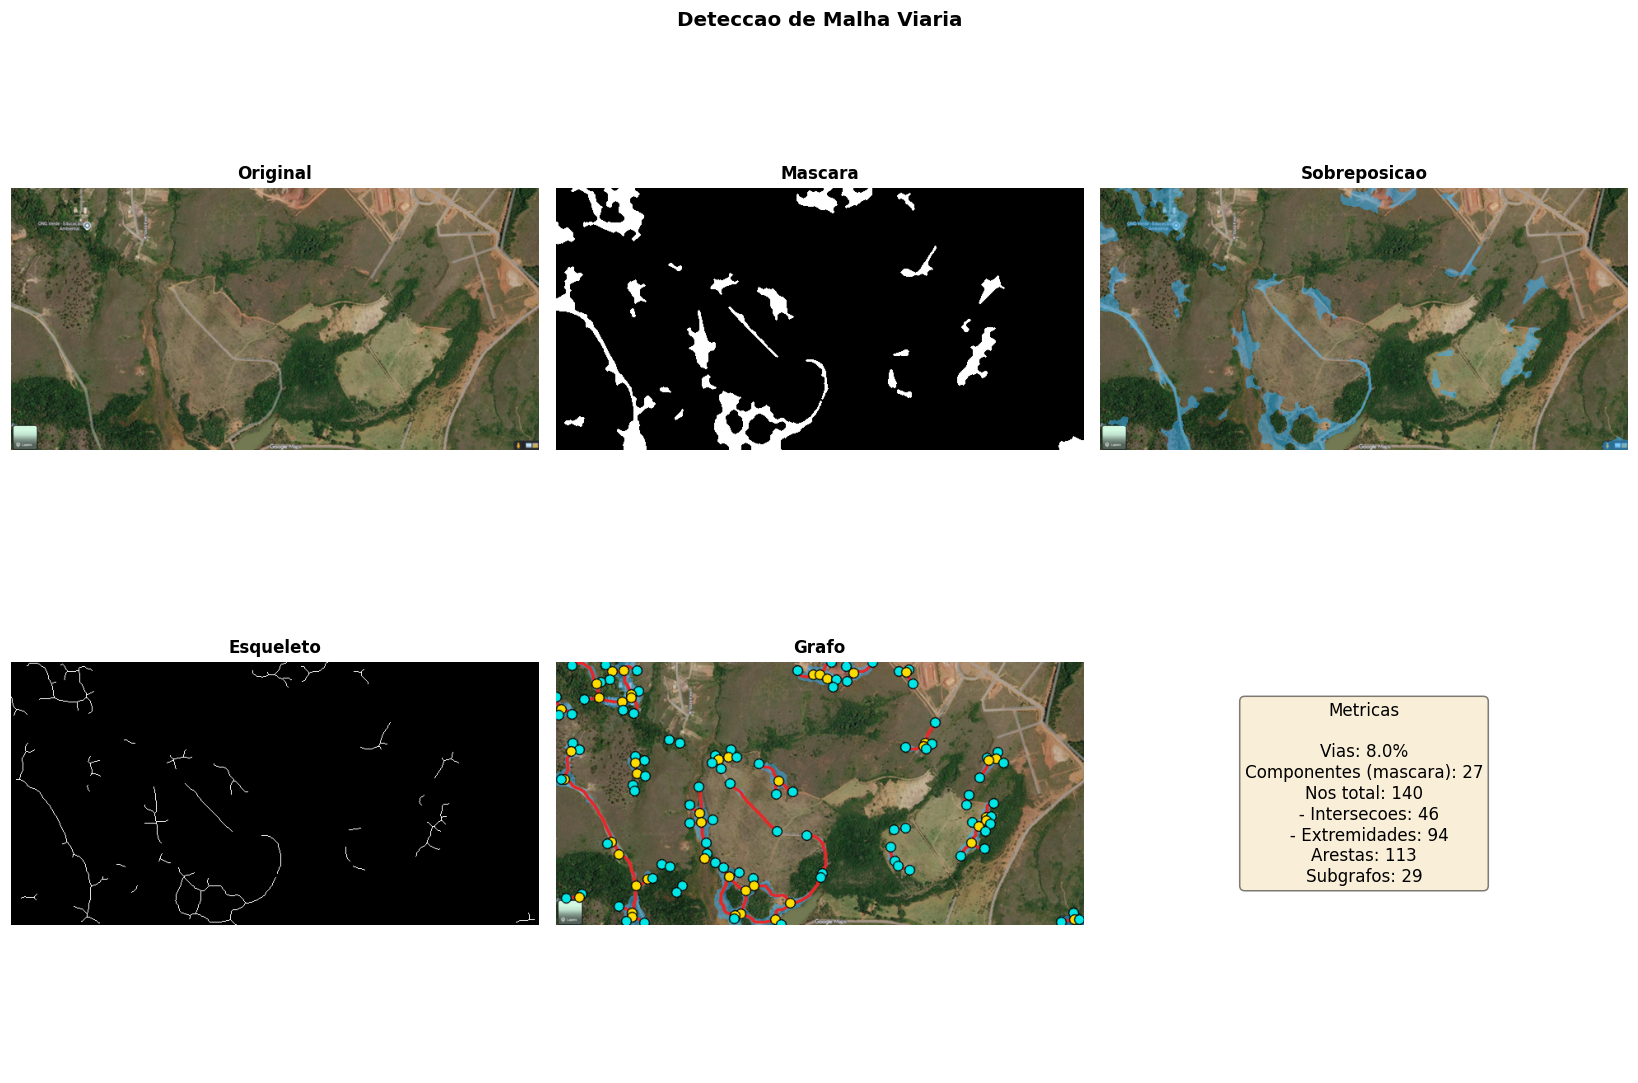

In [69]:
def make_overlay(rgb: np.ndarray, mask: np.ndarray,
                  color: tuple = (50, 180, 255), alpha: float = 0.5) -> np.ndarray:
    """Sobrepoe a mascara de vias na imagem original com transparencia."""
    overlay = rgb.copy().astype(np.float32)
    c = np.array(color, dtype=np.float32)
    overlay[mask] = (1 - alpha) * overlay[mask] + alpha * c
    return overlay.astype(np.uint8)


def draw_graph_on_image(rgb: np.ndarray, G: nx.Graph) -> np.ndarray:
    """Desenha arestas e nos do grafo sobre a imagem."""
    canvas = rgb.copy()
    for _, _, data in G.edges(data=True):
        pts = data.get("points", [])
        if len(pts) >= 2:
            arr = np.array(pts, dtype=np.int32).reshape(-1, 1, 2)
            cv2.polylines(canvas, [arr], False, (230, 40, 40), 2, cv2.LINE_AA)
    for _, data in G.nodes(data=True):
        x = int(round(data.get("x", 0)))
        y = int(round(data.get("y", 0)))
        color = (255, 220, 0) if data.get("tipo") == "intersecao" else (0, 230, 230)
        cv2.circle(canvas, (x, y), 5, color, -1, cv2.LINE_AA)
        cv2.circle(canvas, (x, y), 6, (0, 0, 0), 1, cv2.LINE_AA)
    return canvas


# Monta imagens de saida
rgb = pre["rgb"]
overlay   = make_overlay(rgb, mask)
graph_img = draw_graph_on_image(overlay.copy(), graph)

# Painel 2x3
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

panels = [
    ("Original",     rgb,       None),
    ("Mascara",      mask,      "gray"),
    ("Sobreposicao", overlay,   None),
    ("Esqueleto",    skeleton,  "gray"),
    ("Grafo",        graph_img, None),
]
for ax, (title, img, cmap) in zip(axes, panels):
    ax.imshow(img, cmap=cmap)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.axis("off")

# Sexto painel: metricas
axes[5].axis("off")
n_inter = sum(1 for _, d in graph.nodes(data=True) if d.get("tipo") == "intersecao")
n_ext   = sum(1 for _, d in graph.nodes(data=True) if d.get("tipo") == "extremidade")
axes[5].text(
    0.5, 0.5,
    f"Metricas\n\n"
    f"Vias: {mask.sum()/mask.size*100:.1f}%\n"
    f"Componentes (mascara): {n_comp}\n"
    f"Nos total: {graph.number_of_nodes()}\n"
    f"  - Intersecoes: {n_inter}\n"
    f"  - Extremidades: {n_ext}\n"
    f"Arestas: {graph.number_of_edges()}\n"
    f"Subgrafos: {nx.number_connected_components(graph)}",
    ha="center", va="center", fontsize=11,
    transform=axes[5].transAxes,
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
)

fig.suptitle("Deteccao de Malha Viaria", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()


In [70]:
# ---------------------------------------------------------------------------
# Salva resultados em data/results/ e data/graphs/
# ---------------------------------------------------------------------------

def save_results(pre: dict, mask: np.ndarray, skeleton: np.ndarray,
                 graph_img: np.ndarray, G: nx.Graph,
                 results_dir: Path, graphs_dir: Path, stem: str = "resultado") -> None:
    results_dir.mkdir(parents=True, exist_ok=True)
    graphs_dir.mkdir(parents=True, exist_ok=True)

    rgb = pre["rgb"]
    ov  = make_overlay(rgb, mask)

    def save_rgb(name, img):
        cv2.imwrite(str(results_dir / name), cv2.cvtColor(img, cv2.COLOR_RGB2BGR))

    cv2.imwrite(str(results_dir / f"{stem}_mascara.png"),    mask.astype(np.uint8) * 255)
    cv2.imwrite(str(results_dir / f"{stem}_esqueleto.png"),  skeleton.astype(np.uint8) * 255)
    save_rgb(f"{stem}_sobreposicao.png", ov)
    save_rgb(f"{stem}_grafo.png",        graph_img)

    # Grafo em GraphML
    nx.write_graphml(G, str(graphs_dir / f"{stem}_grafo.graphml"))

    print(f"Resultados salvos em {results_dir}")
    print(f"Grafo salvo em {graphs_dir}")


stem = imgs[0].stem if imgs else "demo_sintetico"
save_results(pre, mask, skeleton, graph_img, graph, RESULTS_DIR, GRAPHS_DIR, stem=stem)


TypeError: GraphML does not support type <class 'list'> as data values.